In [6]:
gen_report = False

In [165]:
import os
import json
import pandas as pd

root = "experiments"

records = []

for dirpath, dirnames, filenames in os.walk(root):
    if "report.json" in filenames:
        report_path = os.path.join(dirpath, "report.json")

        with open(report_path, "r") as f:
            data = json.load(f)

        record = {}

        record["VQEL"] = data.get("VQEL")

        # metrics
        for k, v in data.get("metrics", {}).items():
            record[k] = v

        # config
        for k, v in data.get("config", {}).items():
            if 'dir' in k.lower() or 'split' in k.lower():
                continue
            record[k] = v

        record["path"] = dirpath.replace('experiments/', '').replace('/results', '')
        records.append(record)

df = pd.DataFrame(records)
df.to_csv('VQTT_results.csv', index=False)
df = pd.read_csv('VQTT_results.csv')
df.to_pickle('VQTT_results.pkl')
df = pd.read_pickle('VQTT_results.pkl')

df["reset_unfrozen_params"] = df["reset_unfrozen_params"].map({True: "yes", False: "no"})
df["freeze_codebook"] = df["freeze_codebook"].map({True: "yes", False: "no"})
df["freeze_object_encoder"] = df["freeze_object_encoder"].map({True: "yes", False: "no"})

df.loc[df["num_iterations"] == 0, "learning_rate_tt"] = "-"
df.loc[df["agent_a_training_mode"] == 'frozen', "learning_rate_phase2_a"] = "-"
df.loc[df["best_of_n"].isna(), "best_of_n"] = 1
df.loc[df["dataset_tt"].isna(), "dataset_tt"] = "one_shape"
df.loc[df["sampling_temperature_tt"].isna(), "sampling_temperature_tt"] = df["sampling_temperature"]
df.loc[df["gumbel"].isna(), "gumbel"] = False

df.loc[(df["num_iterations"] == 0) | (df["best_of_n"] == 1), "test_time_mode"] = "-"

df.rename(columns={"test_time_training_accuracy": "test_time_mutual_accuracy"}, inplace=True)
df.rename(columns={"test_time_self_play_accuracy": "test_time_self_accuracy"}, inplace=True)

df["test_time_mode"] = df["test_time_mode"].replace("adaptation", "sample_adaptation")
df["dataset"] = df["dataset"].replace("shape", "shape1")
df["dataset_tt"] = df["dataset_tt"].replace("two_shape", "shape2")
df["dataset_tt"] = df["dataset_tt"].replace("shape_unique_double_attribute", "dual_attribute_shape")
# df["dataset_tt"] = df["dataset_tt"].replace("shape_unique_double_attribute", "single_attribute_shape")

df.loc[df["baseline"].isna(), "baseline"] = False

df.loc[df["baseline"], "test_time_mode"] = "-"

df["test_time_mutual_accuracy"] = df["test_time_mutual_accuracy"] * 100
df["test_time_self_accuracy"] = df["test_time_self_accuracy"] * 100

df = df.where(pd.notna(df), "None")
pd.options.display.float_format = '{:.10g}'.format
df = df.map(lambda x: f"{x:.0e}" if isinstance(x, (int, float)) and x != 0 and (abs(x) < 0.01 or abs(x) == 0.1 or abs(x) == 0.01) else x)
print("Total reports loaded:", len(df))

pd.set_option('display.max_rows', None)

Total reports loaded: 5874


/tmp/ipykernel_10755/3267398569.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["num_iterations"] == 0, "learning_rate_tt"] = "-"
/tmp/ipykernel_10755/3267398569.py:44: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["agent_a_training_mode"] == 'frozen', "learning_rate_phase2_a"] = "-"


In [8]:
def filter_df(filters, df=df, sort_by=["message_length", "message_length_tt", "learning_rate_tt", "num_iterations"]):

    idx = pd.Series(True, index=df.index)

    for key, values in filters.items():
        mask = pd.Series(False, index=df.index)
        if not isinstance(values, (list, tuple, set)):
            values = [values]
        for value in values:
            if (type(value) == str) and value.startswith('>'):
                mask |= (df[key] > value.split('>')[1])
            if value == "!None":
                mask |= (df[key] != "None")
            else:
                mask |= (df[key] == value)
        idx &= mask 

    return df[idx].sort_values(by=sort_by).reset_index(drop=True)

    

In [9]:
import base64

def to_html(df):    

    # ---- highlight rule ----
    # if 'mutual_play_accuracy' in df:
    #     max_col = 'mutual_play_accuracy'
    # else:
    #     max_col = 'test_accuracy'
    # max_val = pd.to_numeric(df[max_col]).max()

    # def highlight_max_row(row):
    #     if  pd.to_numeric(row[max_col]) == max_val:
    #         return ['font-weight: bold; background-color: #ffff99'] * len(row)
    #     else:
    #         return [''] * len(row)

    # ---- style ----
    styled = (
        df.style
            # .apply(highlight_max_row, axis=1)  # <<< APPLY HIGHLIGHT HERE
            .hide(axis="index")
            .format(
                lambda x: (
                    f"{int(x)}"                      # 20.0 -> 20
                    if isinstance(x, float) and x.is_integer()
                    else f"{x:.0e}"                  # small numbers -> scientific
                    if isinstance(x, (int, float)) and x != 0 and abs(x) < 0.01
                    else x
                )
            )
            .set_table_styles([
                {"selector": "td", "props": [("border-right", "1px solid black")]},
                {"selector": "th", "props": [
                    ("border-right", "1px solid black"),
                    ("color", "darkblue"),
                    ("font-weight", "bold"),
                    ("padding-left", "8px"),
                    ("padding-right", "8px")
                ]},
            ])
            .set_properties(**{"text-align": "center"})
    )

    html_table = styled.to_html(index=False)

    if gen_report:
        with open("results.html", "a") as f:
            f.write(html_table)

        
def add_heading(num=1, title=""):
    """Add a professional-colored heading to results.html"""
    colors = ["#0b3d91",  # dark blue
              "#800000",  # maroon
              "#205522",  # dark green
              "#111011",  # indigo
              "#444444"]  # dark gray
    color = colors[(num-1) % len(colors)]  # cycle through colors
    
    if gen_report:
        with open("results.html", "a") as f:
            f.write(f'<h{num} style="color:{color}; font-family:Arial, sans-serif;">{title}</h{num}>\n')
        
def clear():
    if gen_report:
        with open("results.html", "w") as f:
            f.write("")

def line():
    if gen_report:
        with open("results.html", "a") as f:
            f.write('<hr style="border:1px solid #444; margin:10px 0;">\n')
        
        
def write(text):
    html_text = text.replace("\n", "<br>\n")
    
    if gen_report:
        with open("results.html", "a") as f:
            f.write(f"{html_text}\n")


def add_plot(path="plot.png"):
    """Embed an image file directly into results.html using base64."""
    with open(path, "rb") as img:
        encoded = base64.b64encode(img.read()).decode("utf-8")

    html_img = (
        '<img src="data:image/png;base64,' +
        encoded +
        '" style="max-width:650px; height:auto;"><br>\n'
    )

    if gen_report:
        with open("results.html", "a") as f:
            f.write(html_img)
        
    if os.path.exists(path):
        os.remove(path)

In [10]:
import os
import shutil

def remove_expr(res_df):
    for path in res_df["path"]:
        full_path = os.path.join("experiments", path)

        if not os.path.isdir(full_path):
            print(f"[SKIP] Not found: {full_path}")
            continue

        answer = input(f"⚠️ Delete expr '{path}' ? (y/n): ").strip().lower()

        if answer == "y":
            shutil.rmtree(full_path)
            print(f"✅ Deleted: {path}")
        else:
            print(f"❌ Skipped: {path}")

In [11]:
metrics = [
    # "unique_messages"
]

In [12]:
from itertools import product
import pandas as pd


def extract_maxes(df, cols=["message_length", "message_length_tt", "seed"], max_col="test_time_mutual_accuracy"):
    values = []
    for col in cols:
        value = set(df[col])
        values.append(value)

    combinations = [list(x) for x in product(*values)]

    maxes = []
    for comb in combinations:
        section = filter_df({col: value for col, value in zip(cols, comb)}, df)
        if not section.empty:
            max_row = section.loc[pd.to_numeric(section[max_col]).idxmax()]
            maxes.append(max_row.to_frame().T)

    final_df = pd.concat(maxes, ignore_index=True)
    return final_df.sort_values(by=cols).reset_index(drop=True)


def mean_and_std(df, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode"], metrics=["test_time_self_accuracy", "test_time_mutual_accuracy"] + metrics):
    rows = []

    for i in range(0, len(df), 3):
        chunk = df.iloc[i:i+3]
        
        rows.append(
            {col: chunk[col].iloc[0] for col in config_cols} | 
            # {metric: f"{pd.to_numeric(chunk[metric]).mean() * 100:.1f} ± {pd.to_numeric(chunk[metric]).std() * 100:.1f}" for metric in metrics}
            {
            metric: (
                None
                if pd.to_numeric(chunk[metric], errors="coerce").dropna().empty
                else f"{pd.to_numeric(chunk[metric], errors='coerce').mean():.1f} ± "
                     f"{pd.to_numeric(chunk[metric], errors='coerce').std():.1f}"
            )
            for metric in metrics
        }
        )

    out = pd.DataFrame(rows)
    return out.sort_values(by=config_cols)
    

In [13]:
def smooth(values, factor=0.5):
    """Exponential moving average smoothing."""
    smoothed = []
    s = values[0]
    for v in values:
        s = factor * s + (1 - factor) * v
        smoothed.append(s)
    return smoothed

In [14]:
import matplotlib.pyplot as plt

METHOD_COLORS = {
    "GS-ST": "#8c2d04",
    "REINFORCE": "#1f77b4",
    "VQEL": "#ff7f0e",
    "VQEL + TTA (Batch)": "#2ca02c",
    "VQEL + TTA (Dataset)": "#9467bd",
    "Scaling": "#7f7f7f",
    "LR = 1e-4": "#8c2d04",
    "LR = 1e-5": "#7f7f7f",
    "LR = 1e-6": "#2ca02c",
}


def plot(
    dfs,
    labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "VQEL + TTA (Dataset)", "Scaling"),
    name="name",
    xcol="message_length_tt",
    xlabel="Message Length",
    marker="o",
    smooth_factor=0,
    xticks=None,
    logscale=False,
    base=10,
    grid=True
    ):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

    all_x = []

    for df, label in zip(dfs, labels):
        if label not in METHOD_COLORS:
            raise ValueError(f"No color defined for label: {label}")

        color = METHOD_COLORS[label]

        df = df.copy()

        # Split "mean ± std"
        df[["mean_acc", "std_acc"]] = (
            df["test_time_mutual_accuracy"]
            .str.split("±", expand=True)
            .astype(float)
        )

        df = df.sort_values(xcol)

        x = df[xcol]
        y = df["mean_acc"]
        err = df["std_acc"]

        all_x.extend(x.tolist())

        ax.plot(
            x,
            smooth(y, factor=smooth_factor),
            marker=marker,
            linewidth=2,
            color=color,
            label=label,
        )

        ax.fill_between(
            x,
            smooth(y - err, factor=smooth_factor),
            smooth(y + err, factor=smooth_factor),
            color=color,
            alpha=0.2,
            linewidth=0,
        )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Accuracy on OOD Split (\%)", fontsize=12)

    if xticks == None:
        xticks = sorted(set(all_x))
    ax.set_xticks(xticks)
    
    ax.tick_params(axis="both", labelsize=10)

    ax.legend(frameon=False)
    if grid:
        ax.grid(alpha=0.3)
    
    if logscale:
        ax.set_xscale('log', base=base)
    fig.tight_layout()

    plt.savefig(
        f"assets/{name}.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()
    

In [15]:
clear()

---

In [16]:

gumbel_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "learning_rate_phase2_a", 
    "learning_rate_phase2_b",
    "tau_0",
    "mutual_play_accuracy",
    "sampling_temperature",
    "test_time_mode",
    "path",
]

backbone_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "learning_rate_phase1", 
    "learning_rate_phase2_a", 
    "learning_rate_phase2_b",
    "test_time_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
    "path",
]

backbone_cols_report = [
    "seed",
    "message_length",
    "agent_a_training_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
]

baseline_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
] + metrics + [
    "path",
]

baseline_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

scaling_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "sampling_temperature_tt",
    "best_of_n",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

scaling_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "sampling_temperature_tt",
    "best_of_n",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

adapt_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

adapt_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

In [17]:
write(
"""
- <b>Shape1</b>: Contains only one shape.

- <b>Shape2</b>: Contains exactly two shapes.

- <b>Shape12</b>: Contains one or two shapes.

- <b>MNIST1</b>: Contains one digit on either the left or right side of the image (the other side is empty).

- <b>MNIST2</b>: Contains two digits.

- <b>ImageNet_same_class</b>: Distractors and targets belong to the same class.

- <b>Single Attribute Shape</b>: Candidates in a batch have two attributes; the value of one attribute is different for all images,
while there is no restriction on the value of the other attribute—it may be the same for some images and different for others.

- <b>Dual-attribute shape</b>: Candidates in a batch have two attributes, and all candidates can be distinguished from one another 
if and only if the values of both attributes are described.
"""
)

# Shape

## Gumbel - ID

In [18]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "None",
    "baseline": True,
    "gumbel": True
}, sort_by=["seed"])
# res[gumbel_cols]

In [19]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
# final[gumbel_cols]

In [20]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,shape1,"[3, 4]",0.8 ± 0.0


## Gumbel - OOD

In [21]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "!None",
    "baseline": True,
    "gumbel": True,
}, sort_by=["message_length_tt", "seed"])
res[baseline_cols + ["unique_messages"]]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy,path,unique_messages
0,1,True,shape1,cosine,"[3, 4]",4,shape2,-,0,39.1,20260222_0906_bs32_vocab10_repr1024_msg_len4_l...,797
1,2,True,shape1,cosine,"[3, 4]",4,shape2,-,0,39.3,20260222_1636_bs32_vocab10_repr1024_msg_len4_l...,738
2,3,True,shape1,cosine,"[3, 4]",4,shape2,-,0,38,20260222_1639_bs32_vocab10_repr1024_msg_len4_l...,685
3,1,True,shape1,cosine,"[3, 4]",5,shape2,-,0,40,20260222_0907_bs32_vocab10_repr1024_msg_len5_l...,1129
4,2,True,shape1,cosine,"[3, 4]",5,shape2,-,0,39.3,20260222_1637_bs32_vocab10_repr1024_msg_len5_l...,1011
5,3,True,shape1,cosine,"[3, 4]",5,shape2,-,0,39.3,20260222_1639_bs32_vocab10_repr1024_msg_len5_l...,949
6,1,True,shape1,cosine,"[3, 4]",6,shape2,-,0,40.2,20260222_0907_bs32_vocab10_repr1024_msg_len6_l...,1348
7,2,True,shape1,cosine,"[3, 4]",6,shape2,-,0,37.7,20260222_1637_bs32_vocab10_repr1024_msg_len6_l...,1218
8,3,True,shape1,cosine,"[3, 4]",6,shape2,-,0,39.2,20260222_1639_bs32_vocab10_repr1024_msg_len6_l...,1163
9,1,True,shape1,cosine,"[3, 4]",7,shape2,-,0,39.4,20260222_0907_bs32_vocab10_repr1024_msg_len7_l...,1492


In [22]:
gumbel = mean_and_std(res, metrics=["test_time_self_accuracy", "test_time_mutual_accuracy", "unique_messages"])
gumbel

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy,unique_messages
0,shape1,"[3, 4]",4,shape2,-,0.0 ± 0.0,38.8 ± 0.7,740.0 ± 56.0
1,shape1,"[3, 4]",5,shape2,-,0.0 ± 0.0,39.5 ± 0.4,1029.7 ± 91.4
2,shape1,"[3, 4]",6,shape2,-,0.0 ± 0.0,39.0 ± 1.3,1243.0 ± 95.0
3,shape1,"[3, 4]",7,shape2,-,0.0 ± 0.0,39.0 ± 1.2,1397.7 ± 82.0
4,shape1,"[3, 4]",8,shape2,-,0.0 ± 0.0,38.5 ± 1.7,1517.3 ± 62.2
5,shape1,"[3, 4]",9,shape2,-,0.0 ± 0.0,36.8 ± 2.3,1622.0 ± 46.5
6,shape1,"[3, 4]",10,shape2,-,0.0 ± 0.0,34.4 ± 2.5,1698.3 ± 26.4
7,shape1,"[3, 4]",11,shape2,-,0.0 ± 0.0,31.9 ± 2.2,1766.0 ± 26.6
8,shape1,"[3, 4]",12,shape2,-,0.0 ± 0.0,29.8 ± 2.8,1814.7 ± 27.2
9,shape1,"[3, 4]",13,shape2,-,0.0 ± 0.0,27.0 ± 3.0,1848.7 ± 36.1


## REINFORCE - ID

In [23]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "None",
    "baseline": True,
    "gumbel": False
}, sort_by=["seed"])
# res[backbone_cols]

In [24]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,shape1,"[3, 4]",0.9 ± 0.0


## REINFORCE - OOD

In [25]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "!None",
    "baseline": True,
    "gumbel": False
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [26]:
REINFORCE = mean_and_std(res)
# REINFORCE

## VQEL - ID

In [27]:
add_heading(2, "Shape1")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-",
    "dialogued_checkpoint": "None",
}, sort_by=["message_length"])
res = extract_maxes(res, max_col="mutual_play_accuracy")
# res[backbone_cols]

In [28]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,shape1,"[3, 4]",0.8 ± 0.0,0.9 ± 0.0


## VQEL - OOD

In [29]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dataset_tt": "shape2",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-"
}, sort_by=["message_length_tt", "seed"])

to_html(res[baseline_cols_report])

# res[baseline_cols]

In [30]:
VQ_NoTT = mean_and_std(res)
# VQ_NoTT

## Scaling

In [31]:
add_heading(3, "Scaling")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": "scaling"
}, sort_by=["message_length", "message_length_tt", "seed", "sampling_temperature_tt", "best_of_n"])

to_html(res[scaling_cols_report])

# res[scaling_cols]

In [32]:
final = extract_maxes(res)
# final[scaling_cols]

In [33]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [34]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": ["batch_adaptation"],
}, sort_by=["message_length_tt","seed", "learning_rate_tt"])

# res[adapt_cols]

In [35]:
final = extract_maxes(res)
# final[adapt_cols]

In [36]:
batch_adapt = mean_and_std(final)
# batch_adapt

## Dataset Adaptation

In [37]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": ["dataset_adaptation"],
}, sort_by=["message_length_tt","seed", "learning_rate_tt"])
# res[adapt_cols]

In [38]:
final = extract_maxes(res)
# final[adapt_cols]

In [39]:
dataset_adapt = mean_and_std(final)
# dataset_adapt

## Plot

In [40]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="shape")

In [41]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="shape-scaling")

# MNIST

## Gumbel - ID

In [42]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "None",
    "gumbel": True,
    "number_of_candidates": 100,
}, sort_by=["seed"])

# res[gumbel_cols]

In [43]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
final[gumbel_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase2_a,learning_rate_phase2_b,tau_0,mutual_play_accuracy,sampling_temperature,test_time_mode,path
0,1,True,mnist1,cosine,"[3, 4]",-,1e-05,1e-01,0.808,1e-05,-,20260212_1441_bs32_vocab10_repr192_msg_len4_lr...
1,2,True,mnist1,cosine,"[3, 4]",-,1e-05,1e-01,0.803,1e-05,-,20260216_2326_bs32_vocab10_repr192_msg_len4_lr...
2,3,True,mnist1,cosine,"[3, 4]",-,1e-05,0.3,0.794,1e-05,-,20260217_1444_bs32_vocab10_repr192_msg_len4_lr...


In [44]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,mnist1,"[3, 4]",0.8 ± 0.0


## Gumbel - OOD

In [45]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": True,
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed"])
res[baseline_cols]

,seed,baseline,dataset,sim,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy,path
0,1,True,mnist1,cosine,"[3, 4]",4,mnist2,-,0,27.6,20260222_1710_bs32_vocab10_repr192_msg_len4_lr...
1,2,True,mnist1,cosine,"[3, 4]",4,mnist2,-,0,21.8,20260222_1712_bs32_vocab10_repr192_msg_len4_lr...
2,3,True,mnist1,cosine,"[3, 4]",4,mnist2,-,0,21.8,20260222_1714_bs32_vocab10_repr192_msg_len4_lr...
3,1,True,mnist1,cosine,"[3, 4]",5,mnist2,-,0,27.6,20260222_1710_bs32_vocab10_repr192_msg_len5_lr...
4,2,True,mnist1,cosine,"[3, 4]",5,mnist2,-,0,22.5,20260222_1712_bs32_vocab10_repr192_msg_len5_lr...
5,3,True,mnist1,cosine,"[3, 4]",5,mnist2,-,0,23.3,20260222_1714_bs32_vocab10_repr192_msg_len5_lr...
6,1,True,mnist1,cosine,"[3, 4]",6,mnist2,-,0,28.1,20260222_1710_bs32_vocab10_repr192_msg_len6_lr...
7,2,True,mnist1,cosine,"[3, 4]",6,mnist2,-,0,20.9,20260222_1712_bs32_vocab10_repr192_msg_len6_lr...
8,3,True,mnist1,cosine,"[3, 4]",6,mnist2,-,0,21.4,20260222_1715_bs32_vocab10_repr192_msg_len6_lr...
9,1,True,mnist1,cosine,"[3, 4]",7,mnist2,-,0,26.3,20260222_1710_bs32_vocab10_repr192_msg_len7_lr...


In [46]:
gumbel = mean_and_std(res)
gumbel

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist2,-,0.0 ± 0.0,23.7 ± 3.3
1,mnist1,"[3, 4]",5,mnist2,-,0.0 ± 0.0,24.5 ± 2.7
2,mnist1,"[3, 4]",6,mnist2,-,0.0 ± 0.0,23.5 ± 4.0
3,mnist1,"[3, 4]",7,mnist2,-,0.0 ± 0.0,21.7 ± 4.0
4,mnist1,"[3, 4]",8,mnist2,-,0.0 ± 0.0,20.2 ± 4.8
5,mnist1,"[3, 4]",9,mnist2,-,0.0 ± 0.0,18.4 ± 4.8
6,mnist1,"[3, 4]",10,mnist2,-,0.0 ± 0.0,16.6 ± 4.7
7,mnist1,"[3, 4]",11,mnist2,-,0.0 ± 0.0,14.3 ± 4.4
8,mnist1,"[3, 4]",12,mnist2,-,0.0 ± 0.0,12.9 ± 4.2
9,mnist1,"[3, 4]",13,mnist2,-,0.0 ± 0.0,11.9 ± 4.4


## REINFORCE - ID

In [47]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "None",
    "gumbel": False,
    "number_of_candidates": 100,
}, sort_by=["seed"])
# res[backbone_cols]

In [48]:
mean_and_std(res)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist1,-,0.0 ± 0.0,86.9 ± 2.3


## REINFORCE - OOD

In [49]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": False,
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [50]:
REINFORCE = mean_and_std(res)
# REINFORCE

## VQEL - ID

In [51]:
add_heading(2, "MNIST")
add_heading(3, 'Base Model')
res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": "[3, 4]",
    "number_of_candidates": 100,
}, sort_by=["message_length", "message_length_tt"])
# res[backbone_cols]

In [52]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,mnist1,"[3, 4]",0.8 ± 0.0,0.9 ± 0.0


## VQEL - OOD

In [53]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "-",
    "number_of_candidates": 100,
}, sort_by=["message_length", "message_length_tt", "seed"])
# res[baseline_cols]

In [54]:
final = extract_maxes(res)
# final[baseline_cols]

In [55]:
VQ_NoTT = mean_and_std(final)
VQ_NoTT

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist2,-,44.5 ± 3.9,42.0 ± 2.8
1,mnist1,"[3, 4]",5,mnist2,-,49.3 ± 4.2,46.0 ± 2.7
2,mnist1,"[3, 4]",6,mnist2,-,51.8 ± 4.7,48.5 ± 2.3
3,mnist1,"[3, 4]",7,mnist2,-,51.6 ± 3.9,49.0 ± 1.7
4,mnist1,"[3, 4]",8,mnist2,-,50.9 ± 3.6,48.1 ± 2.0
5,mnist1,"[3, 4]",9,mnist2,-,48.6 ± 3.5,46.1 ± 1.6
6,mnist1,"[3, 4]",10,mnist2,-,47.1 ± 3.4,43.0 ± 0.6
7,mnist1,"[3, 4]",11,mnist2,-,43.8 ± 3.8,39.2 ± 1.3
8,mnist1,"[3, 4]",12,mnist2,-,41.1 ± 4.2,35.3 ± 1.3
9,mnist1,"[3, 4]",13,mnist2,-,38.9 ± 5.7,33.8 ± 1.3


## Scaling

In [56]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "scaling",
    "sampling_temperature_tt": "1e-02",
    "number_of_candidates": 100,
}, sort_by=["message_length", "message_length_tt", "sampling_temperature_tt", "best_of_n"])
# res[scaling_cols]

In [57]:
final = extract_maxes(res)
# final[scaling_cols]

In [58]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [59]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [60]:
final = extract_maxes(res)
# final[adapt_cols]

In [61]:
batch_adapt = mean_and_std(final)
# batch_adapt

## Dataset Adaptation

In [62]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [63]:
final = extract_maxes(res)
# final[adapt_cols]

In [64]:
dataset_adapt = mean_and_std(final)
# dataset_adapt

## Plot

In [65]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="mnist")

In [66]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="mnist-scaling")

# ImageNet

## Gumbel - ID

In [67]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
    "gumbel": True,
}, sort_by=["message_length", "seed"])
# res[gumbel_cols]

In [68]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
# final[gumbel_cols]

In [69]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
mean

,dataset,message_length,mutual_play_accuracy
0,imagenet,"[2, 3, 4]",0.7 ± 0.0


## Gumbel - OOD

In [70]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": True,
    "dataset_tt": "imagenet_same_class",
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [71]:
gumbel = mean_and_std(res, metrics=["test_time_self_accuracy", "test_time_mutual_accuracy"] + metrics)
# gumbel

## REINFORCE - ID

In [72]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
    "gumbel": False,
}, sort_by=["message_length", "seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,0.859,20251231_1826_bs32_vocab10_repr2048_msg_len4_l...
1,2,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,0.846,20251231_1934_bs32_vocab10_repr2048_msg_len4_l...
2,3,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,0.869,20251231_1958_bs32_vocab10_repr2048_msg_len4_l...


In [73]:
mean_and_std(res)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,imagenet,"[2, 3, 4]",4,imagenet,-,0.0 ± 0.0,85.8 ± 1.2


## REINFORCE - OOD

In [74]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "!None",
    "gumbel": False,
    "dataset_tt": "imagenet_same_class",
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [75]:
final = extract_maxes(res)
# final[baseline_cols]

In [76]:
REINFORCE = mean_and_std(final)
# REINFORCE

## VQEL - ID

In [77]:
add_heading(2, "ImageNet")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "imagenet",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    "message_length": "[2, 3, 4]"
}, sort_by=["vocab_size", "message_length","seed", "message_length_tt"])
# res[backbone_cols]

In [78]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
# mean

## VQEL - OOD

In [79]:
add_heading(3, "Baseline")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": "-",
    "message_length": "[2, 3, 4]"
}, sort_by=["message_length", "message_length_tt", "seed"])
# res[baseline_cols]

In [80]:
VQ_NoTT = mean_and_std(res)
# VQ_NoTT

## Scaling

In [81]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": 'scaling'
}, sort_by=["message_length_tt", "sampling_temperature_tt", "best_of_n"])
# res[scaling_cols]

In [82]:
final = extract_maxes(res)
# final[scaling_cols]

In [83]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [84]:
add_heading(3, "Adaptation")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["batch_adaptation"],
    "message_length": "[2, 3, 4]",
    "num_iterations": [50, 100, 200],
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])
# res[adapt_cols]

In [85]:
final = extract_maxes(res)
# final[adapt_cols]

In [86]:
batch_adapt = mean_and_std(final)
# batch_adapt

## Dataset Adaptation

In [87]:
add_heading(3, "Adaptation")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["dataset_adaptation"],
    "message_length": "[2, 3, 4]",
    "num_iterations": [5, 10, 15, 20],
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])
# res[adapt_cols]

In [88]:
final = extract_maxes(res)
# final[adapt_cols]

In [89]:
dataset_adapt = mean_and_std(final)
# dataset_adapt

## Plot

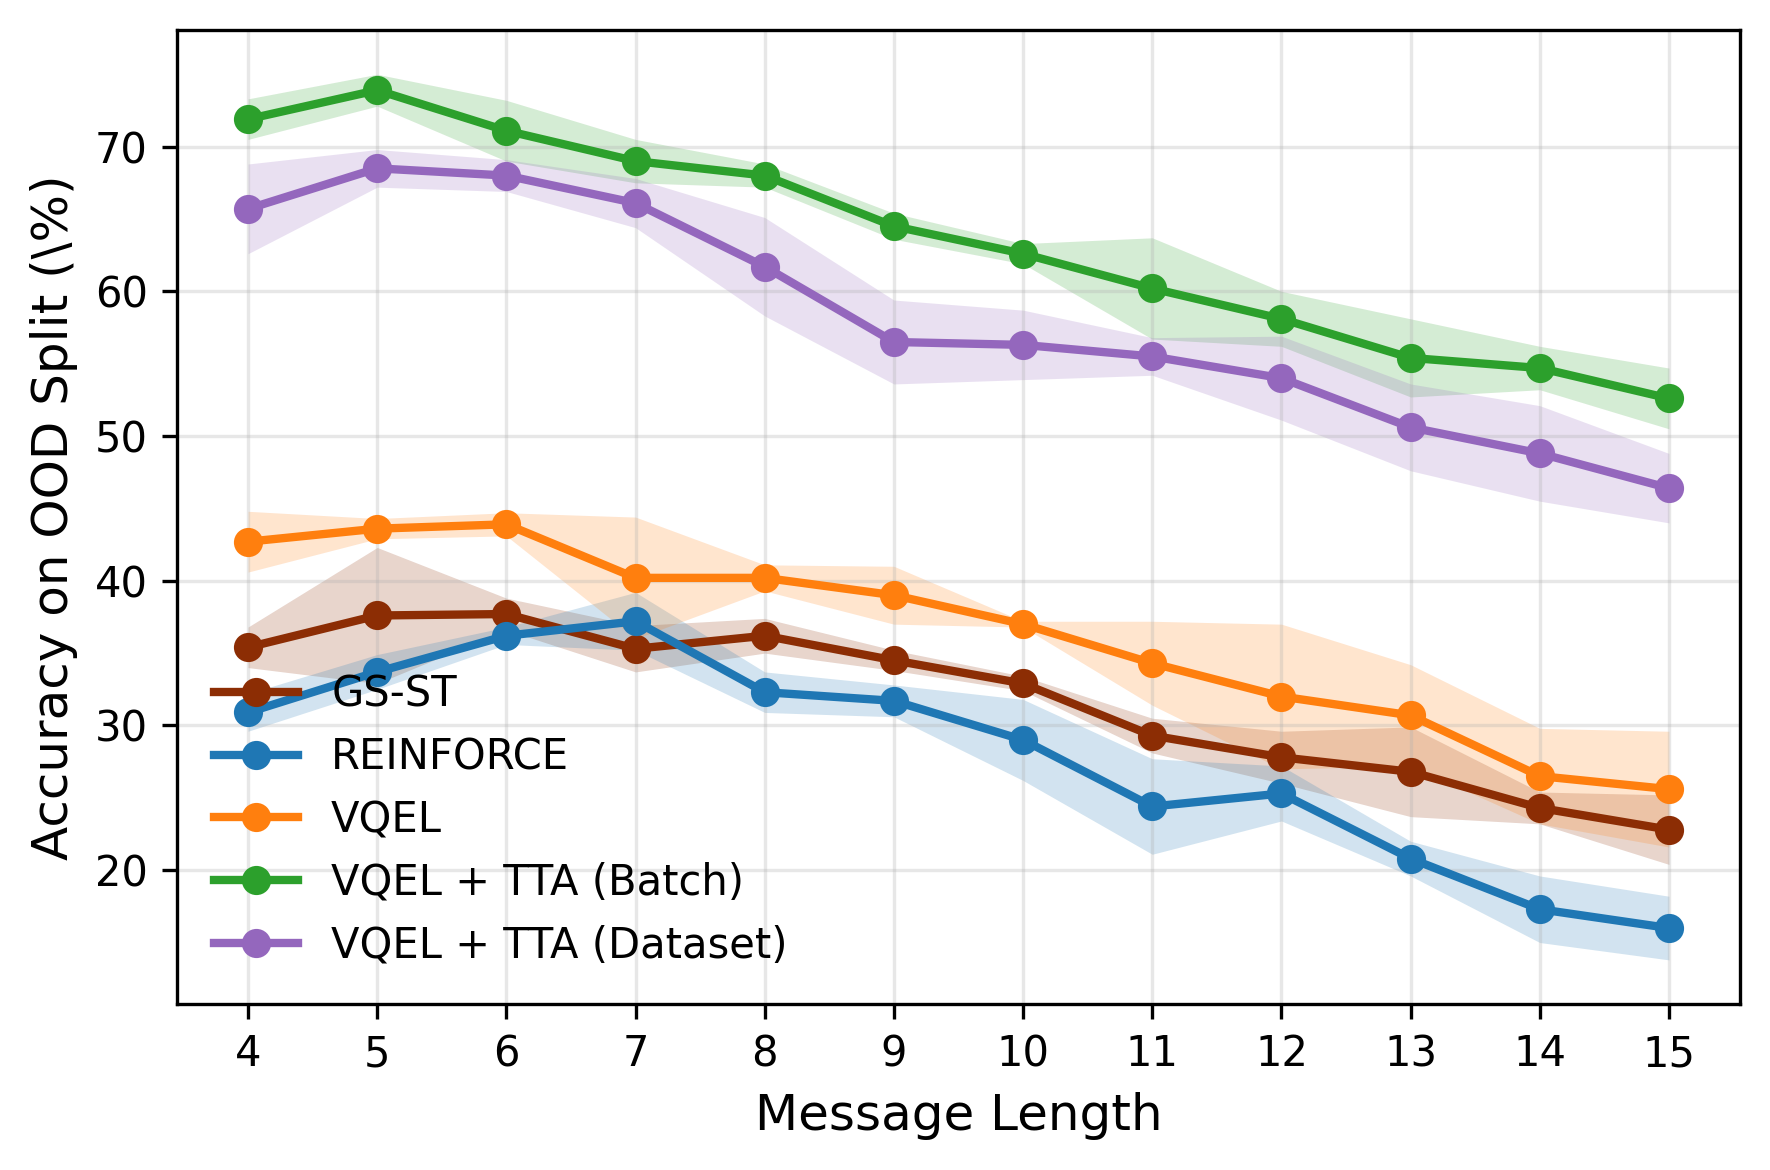

In [90]:
plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="imagenet")

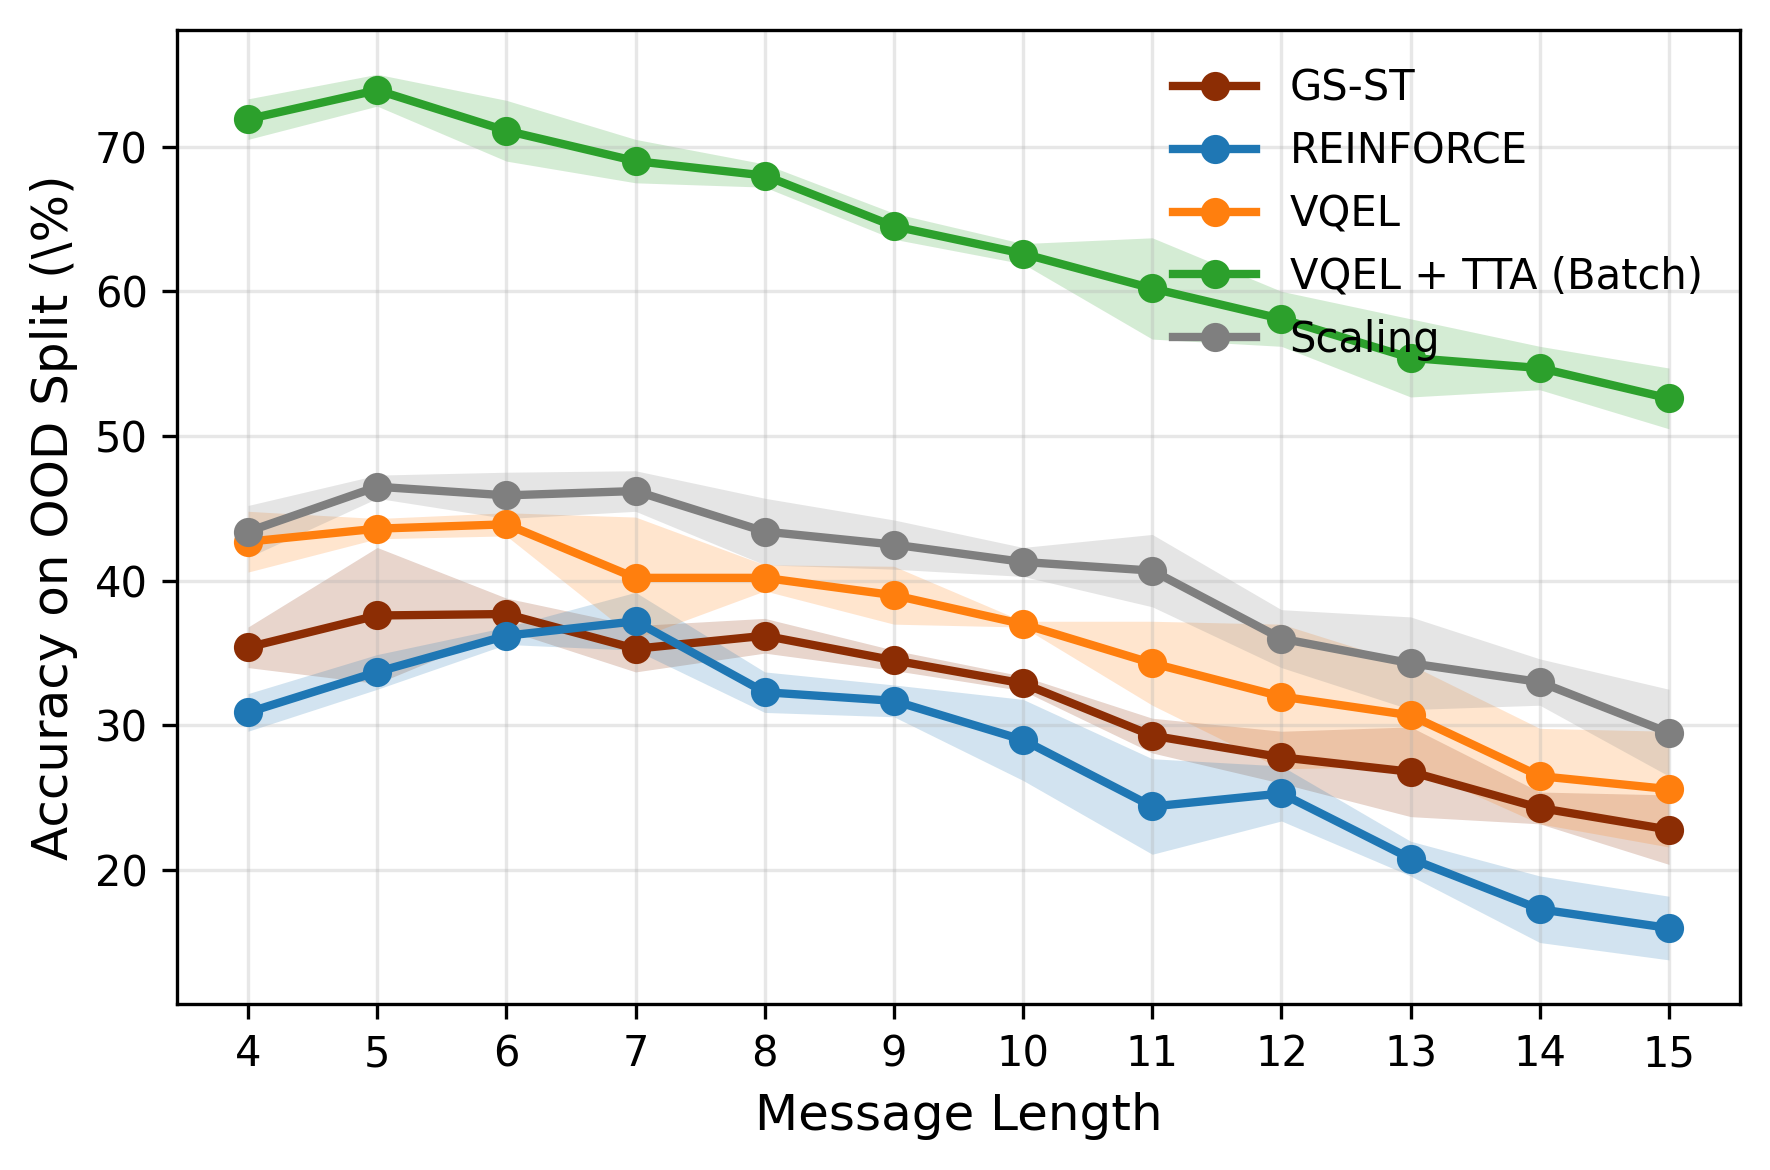

In [91]:
plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="imagenet-scaling")

# Batch Size

In [92]:
adapt_cols = [
    "seed",
    "baseline",
    "dataset",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "number_of_candidates",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

baseline_cols = [
    "seed",
    "baseline",
    "dataset",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "number_of_candidates",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

## ImageNet

In [93]:
number_of_candidates = [2, 4, 8, 16, 32, 64, 118]

### Gumbel - OOD

In [94]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "message_length_tt": 6,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "seed"])

# res[baseline_cols]

In [95]:
gumbel = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### REINFORCE - OOD

In [96]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "message_length_tt": 7,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "seed"])

# res[baseline_cols]

In [97]:
REINFORCE = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### VQEL - OOD

In [98]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "-",
    "message_length_tt": 6,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [99]:
vqel = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])
# vqel

### Batch Adaptation

In [100]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "batch_adaptation",
    "number_of_candidates": number_of_candidates,
    "message_length_tt": 5
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [101]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [102]:
batch_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Dataset Adaptation

In [103]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "dataset_adaptation",
    "number_of_candidates": number_of_candidates,
    "message_length_tt": 5
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [104]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [105]:
dataset_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Plot

In [106]:
# plot([gumbel, REINFORCE, vqel, batch_adapt,dataset_adapt], labels=["GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "VQEL + TTA (Dataset)"], xlabel="Batch size", xcol="number_of_candidates", name="batch/imagenet_batch")

## MNIST

In [107]:
number_of_candidates = [2, 4, 8, 16, 32, 64, 128]

### Gumbel - OOD

In [108]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "message_length_tt": 4,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [109]:
gumbel = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### REINFORCE - OOD

In [110]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "message_length_tt": 5,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [111]:
REINFORCE = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### VQEL - OOD

In [112]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "-",
    "message_length_tt": 7,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [113]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [114]:
vqel = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Batch Adaptation

In [115]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "batch_adaptation",
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [116]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [117]:
batch_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Dataset Adaptation

In [118]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "dataset_adaptation",
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [119]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])

In [120]:
dataset_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Plot

In [121]:
# plot([gumbel, REINFORCE, vqel, batch_adapt, dataset_adapt], labels=["REINFORCE", "GS-ST", "VQEL" ,"VQEL + TTA (Batch)", "VQEL + TTA (Dataset)"], xlabel="Batch size", xcol="number_of_candidates", logscale=False, base=2, name="batch/mnist_batch")

# Learning Rate & Steps

In [122]:
num_iterations = list(range(1, 10)) + list(range(10, 100, 10)) + list(range(100, 1000, 100)) + [1000]

## MNIST

In [123]:
no_adapt = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": ["-"],
    "message_length_tt": 10,
    "learning_rate_tt": '-',
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
# no_adapt[adapt_cols]

### Batch Adaptation

#### LR = 1e-4

In [124]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": ['1e-04'],
    "number_of_candidates": 100,
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [125]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [126]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### LR = 1e-5

In [127]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": ['1e-05'],
    "number_of_candidates": 100,
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [128]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [129]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr5

#### LR = 1e-6

In [130]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 10,
    "number_of_candidates": 100,
    "learning_rate_tt": ['1e-06'],
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [131]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")

In [132]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### Plot

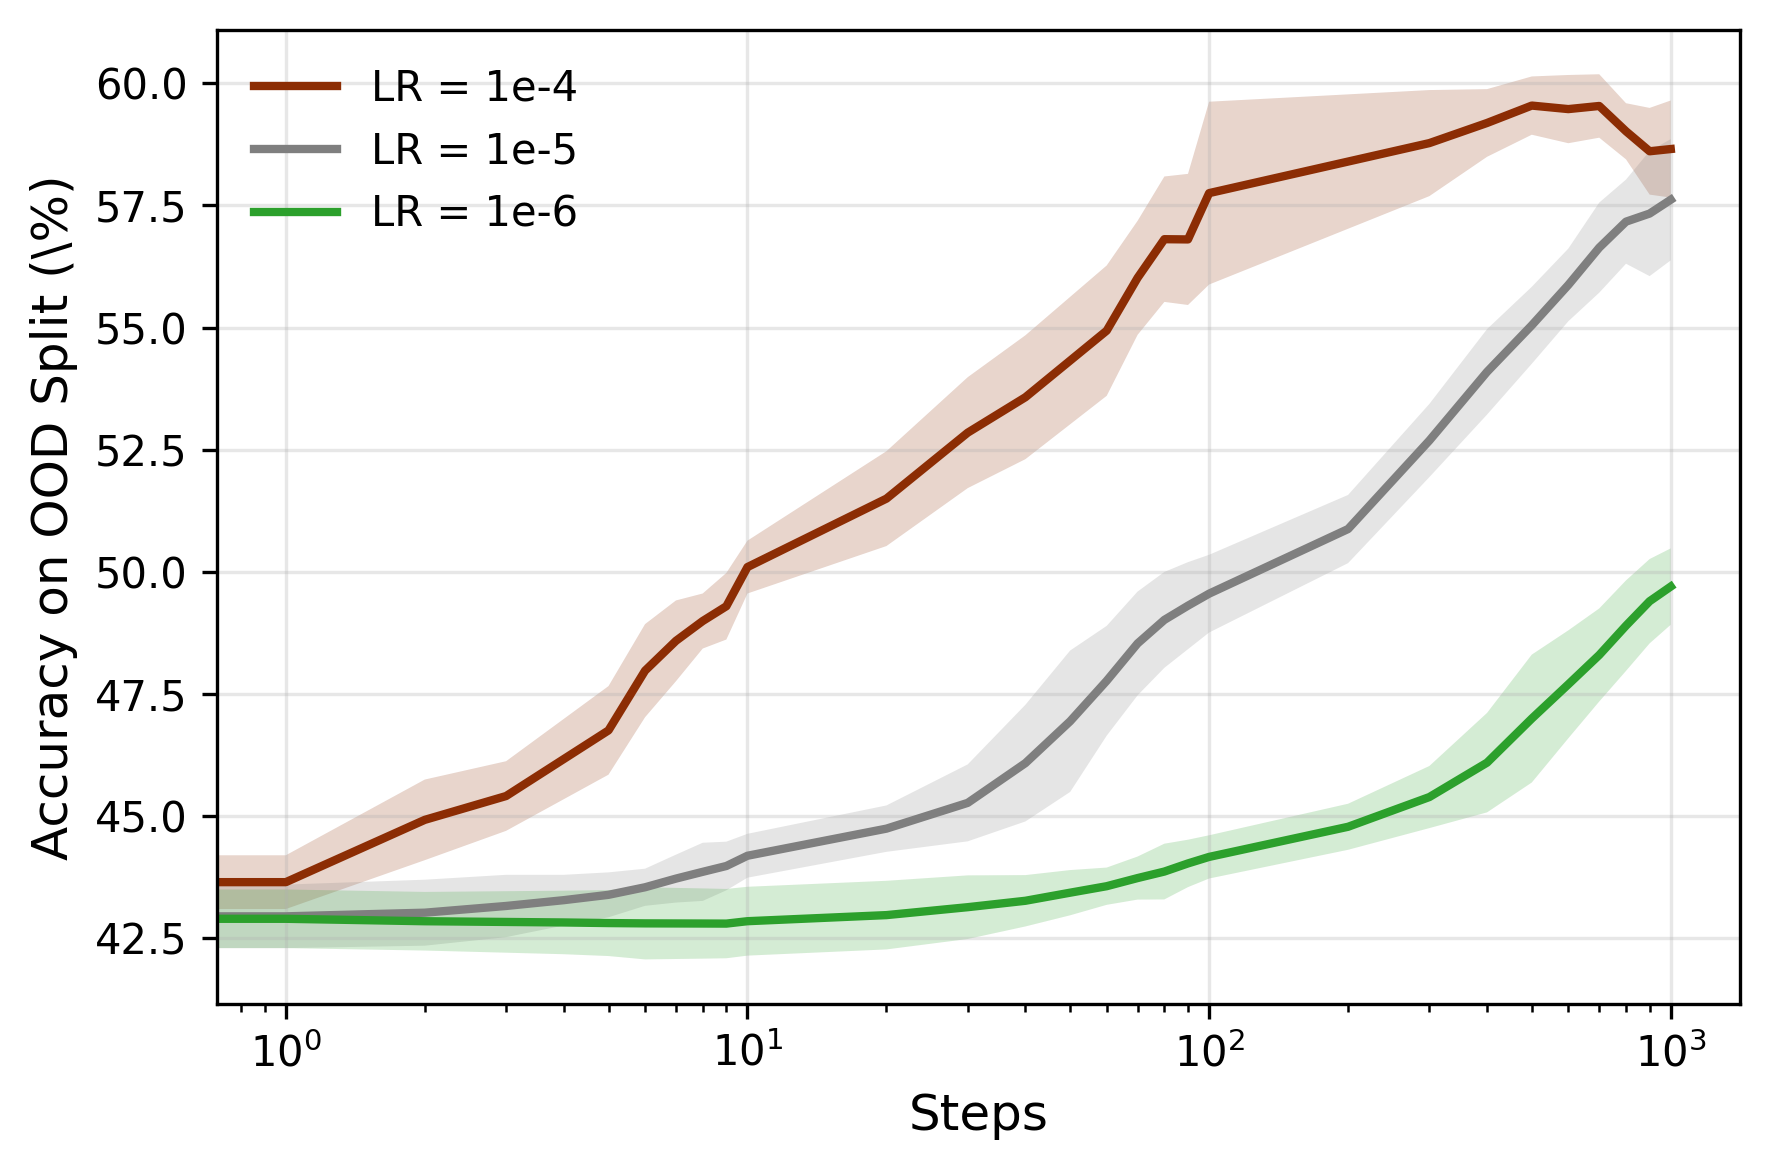

In [133]:
plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=True, xticks=range(0, 1010, 100), smooth_factor=0.5, name="steps/mnist_steps_batch")

### Dataset Adaptation

#### LR = 1e-4

In [134]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": '1e-04',
    "number_of_candidates": 100,
    "path": ">20260300",
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [135]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [136]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr4

#### LR = 1e-5

In [137]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": '1e-05',
    "number_of_candidates": 100,
    "path": ">20260300",
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [138]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [139]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### LR = 1e-6

In [140]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": '1e-06',
    "number_of_candidates": 100,
    "path": ">20260300",
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [141]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [142]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### Plot

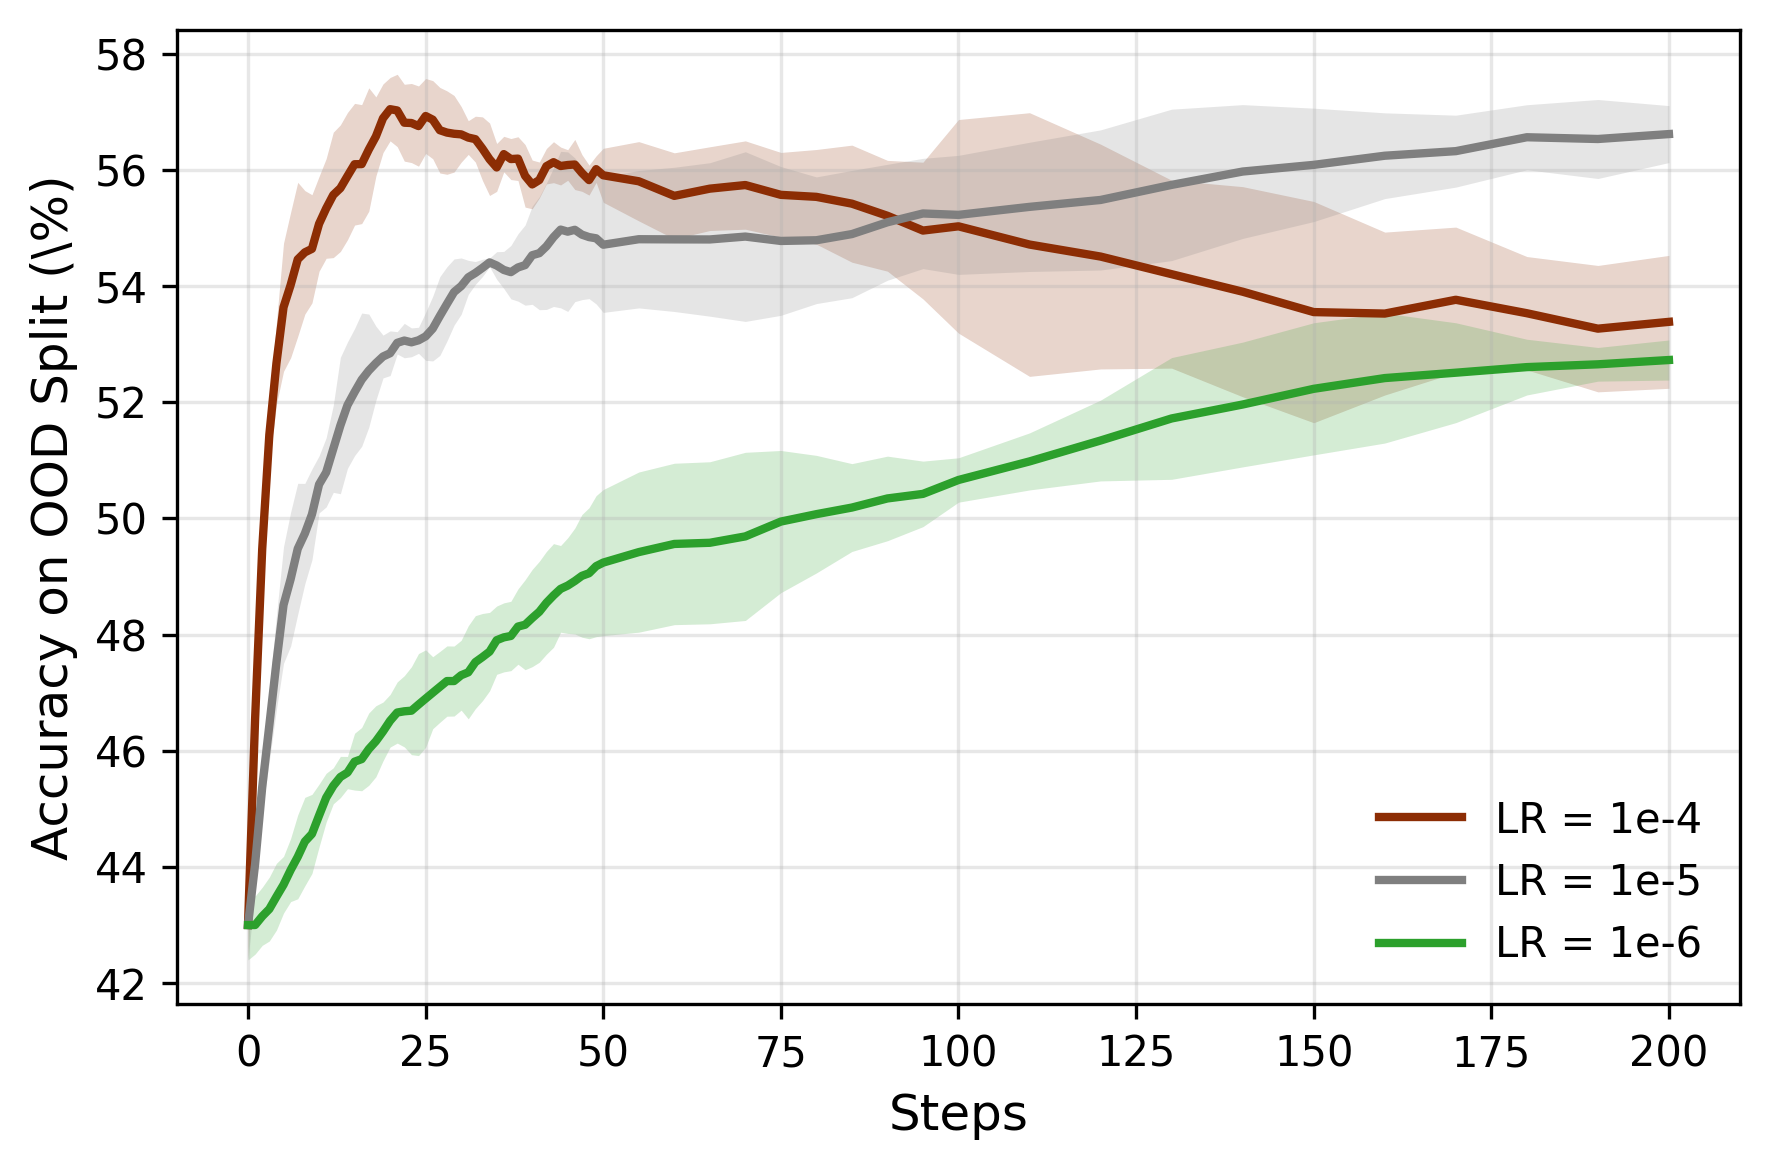

In [143]:
plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=False, smooth_factor=0.5, xticks=range(0, 201, 25), name="steps/mnist_steps_dataset")

## ImageNet

In [144]:
no_adapt = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["-"],
    "message_length_tt": 5,
    "learning_rate_tt": ['-'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
# no_adapt[adapt_cols]

### Batch Adaptation

#### LR = 1e-4

In [145]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": ['1e-04'],
    "message_length": '[2, 3, 4]',
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [146]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [147]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### LR = 1e-5

In [148]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": '1e-05',
    "message_length": '[2, 3, 4]',
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [149]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")


In [150]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr5


#### LR = 1e-6

In [151]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "dataset_tt": "imagenet_same_class",
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": '1e-06',
    "message_length": '[2, 3, 4]',
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [152]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")

In [153]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr6

#### Plot

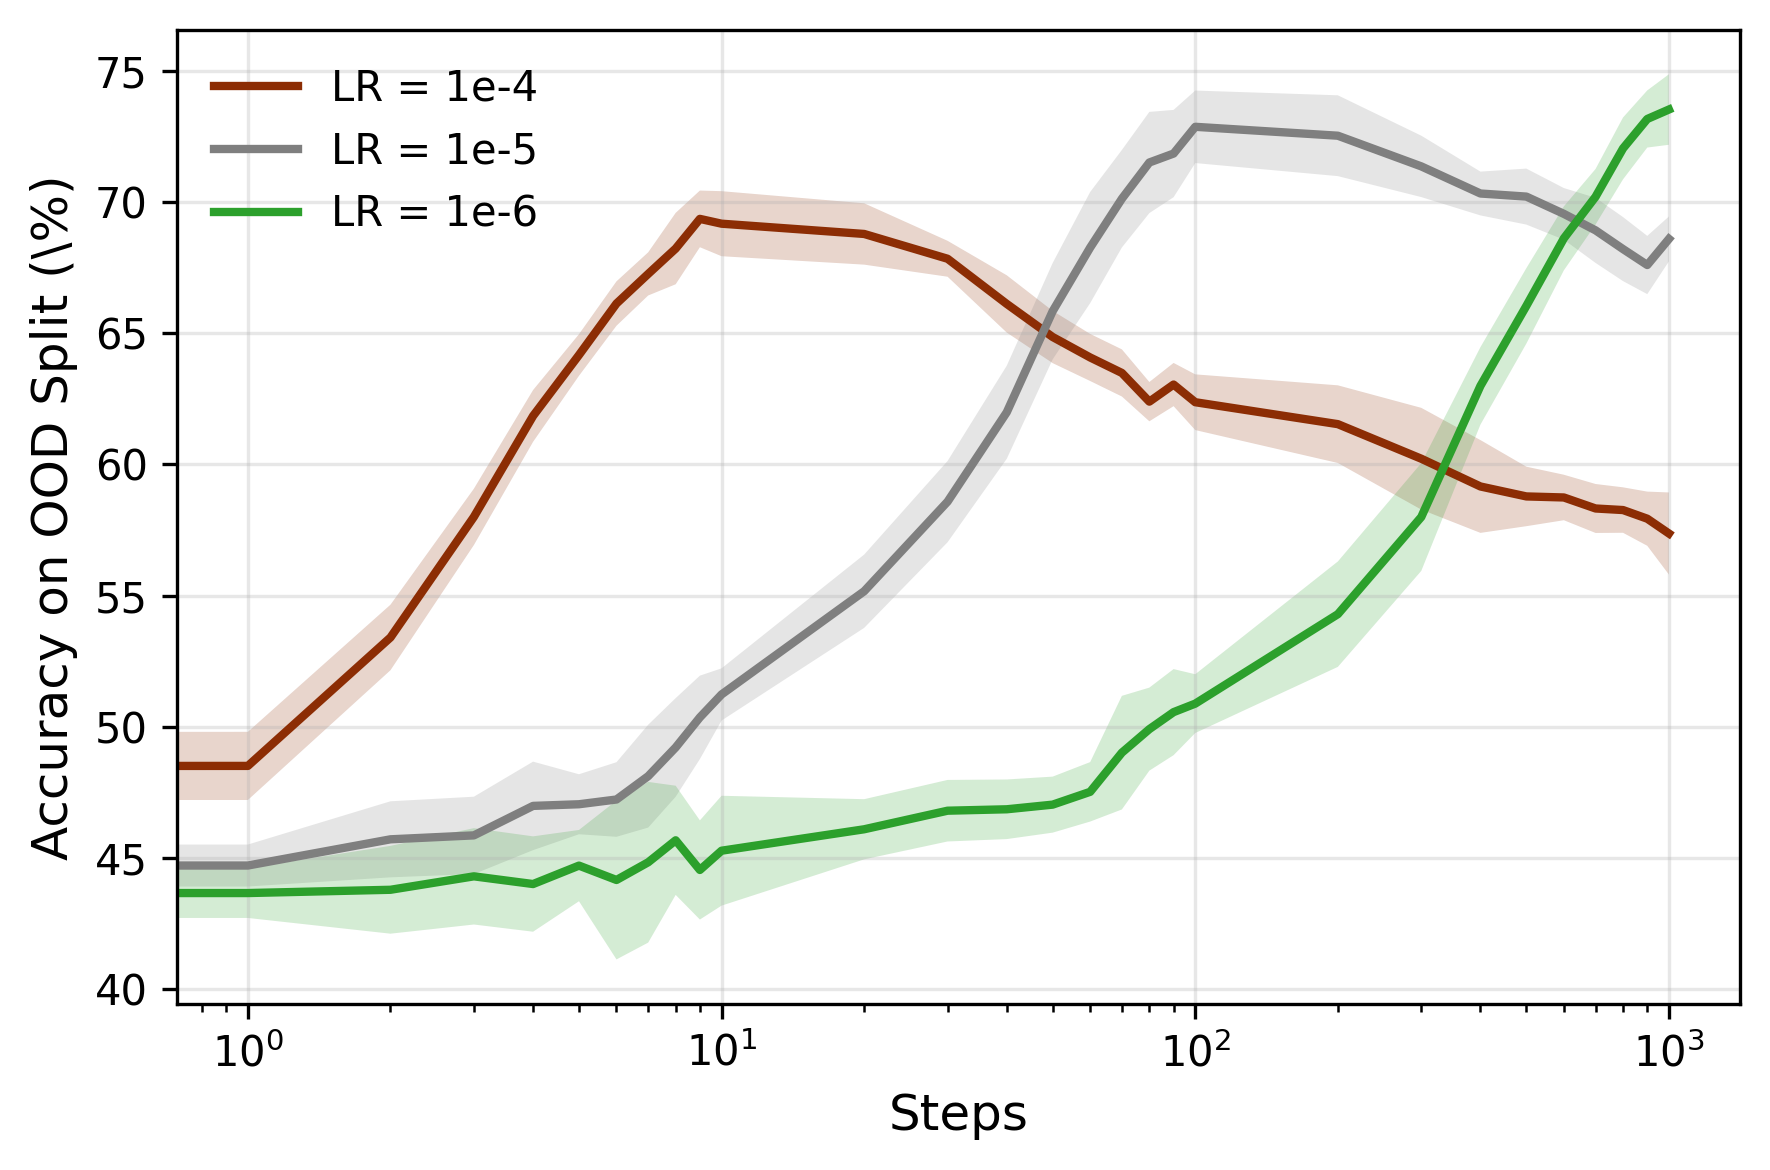

In [154]:
plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=True, xticks=range(0, 1010, 100), smooth_factor=0.5, name="steps/imagenet_steps_batch")

### Dataset Adaptation

#### LR = 1e-4

In [155]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "dataset_tt": "imagenet_same_class",
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": ['1e-04'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [156]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [157]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr4

#### LR = 1e-5

In [158]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "dataset_tt": "imagenet_same_class",
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": ['1e-05'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [159]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [160]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr5

#### LR = 1e-6

In [161]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 5,
    "dataset_tt": "imagenet_same_class",
    "learning_rate_tt": ['1e-06'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])

# res[adapt_cols]

In [162]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")

In [163]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr6

#### Plot

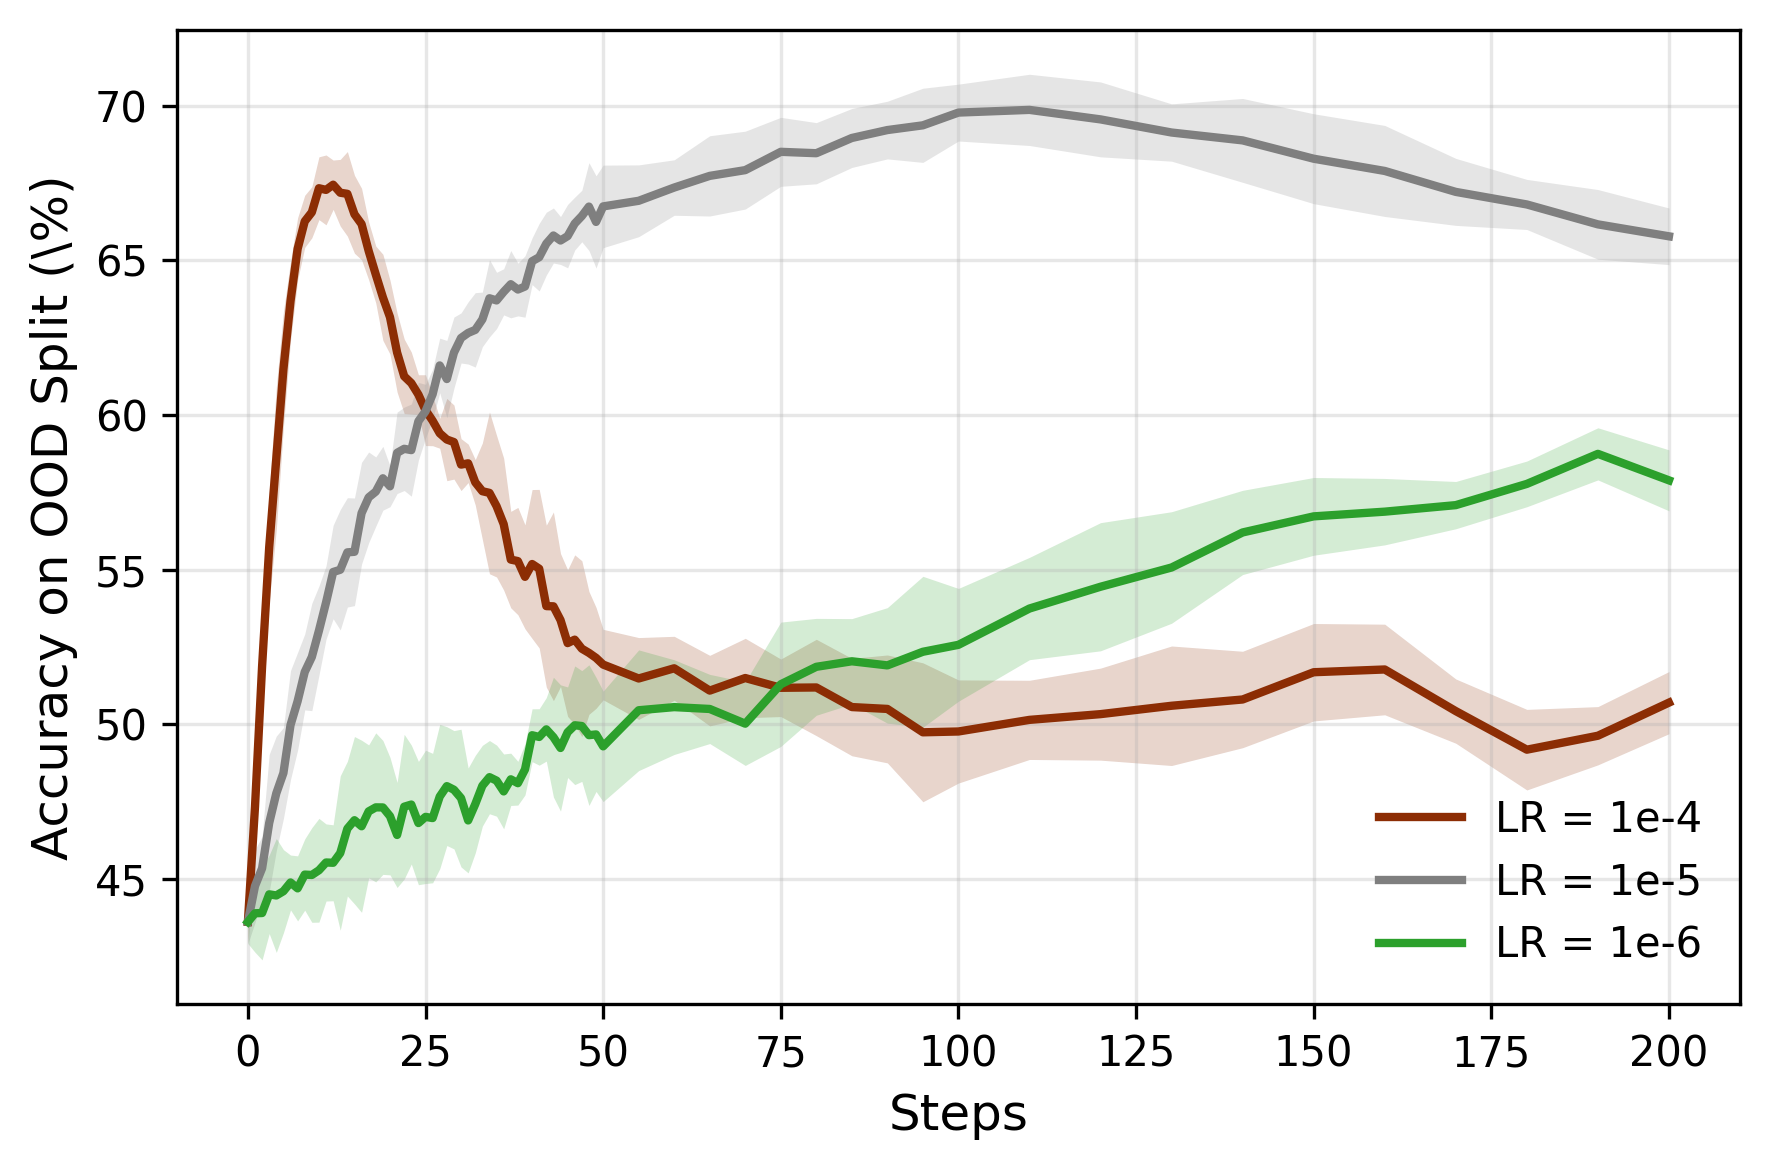

In [164]:
plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=False, smooth_factor=0.6, xticks=range(0, 201, 25), name="steps/imagenet_steps_dataset")